# A6 — K-Means and LDA from Scratch

This notebook implements both algorithms with NumPy; it does **not** use built-in K-Means or LDA functions. Matplotlib is used only for plots. K-Means runs without labels, while LDA uses labels to compute class scatter matrices.

## Method

**K-Means:** initialize K centroids, assign each point to its nearest centroid, replace each centroid by its assigned points' mean, and repeat until stable.

**LDA:** calculate within-class scatter $S_W$ and between-class scatter $S_B$, solve the generalized eigenproblem using $S_W^{-1}S_B$, and project onto the leading directions. For C classes, at most C−1 discriminant components are useful.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

# Reproducible synthetic 2D dataset: three labeled Gaussian groups.
rng = np.random.default_rng(21)
class_centers = np.array([[-3.0, -2.0], [3.0, -2.0], [0.0, 3.0]])
X = np.vstack([rng.normal(center, 0.85, size=(40, 2)) for center in class_centers])
y = np.repeat(np.arange(3), 40)
print('X shape:', X.shape, '| class labels:', np.unique(y))

X shape: (120, 2) | class labels: [0 1 2]


## 1. K-Means implementation

Centroids begin at randomly selected distinct observations. Empty clusters are reinitialized using distant observations. The seed makes the run reproducible.

In [2]:
def kmeans(X, k, seed=7, max_iter=200, tolerance=1e-8):
    X = np.asarray(X, dtype=float)
    if X.ndim != 2 or len(X) == 0:
        raise ValueError('X must be a non-empty 2D array.')
    if not 1 <= k <= len(X):
        raise ValueError('k must be between 1 and the number of samples.')

    rng = np.random.default_rng(seed)
    centroids = X[rng.choice(len(X), size=k, replace=False)].copy()
    previous_labels = None

    for iteration in range(1, max_iter + 1):
        distances = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        labels = np.argmin(distances, axis=1)
        nearest_distances = distances[np.arange(len(X)), labels]
        updated = centroids.copy()
        empty_clusters = []
        for cluster_id in range(k):
            members = X[labels == cluster_id]
            if len(members):
                updated[cluster_id] = members.mean(axis=0)
            else:
                empty_clusters.append(cluster_id)

        farthest = np.argsort(nearest_distances)[::-1]
        used = set()
        for cluster_id in empty_clusters:
            sample_id = next(i for i in farthest if int(i) not in used)
            used.add(int(sample_id))
            updated[cluster_id] = X[sample_id]

        centroids_stable = np.allclose(updated, centroids, atol=tolerance, rtol=0)
        labels_stable = previous_labels is not None and np.array_equal(labels, previous_labels)
        centroids = updated
        if centroids_stable or labels_stable:
            break
        previous_labels = labels.copy()

    distances = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
    labels = np.argmin(distances, axis=1)
    return labels, centroids, iteration

Converged after 5 iterations
Centroids:
 [[-3.059 -1.894]
 [ 2.876 -2.086]
 [-0.103  2.802]]
Cluster sizes: [40 40 40]


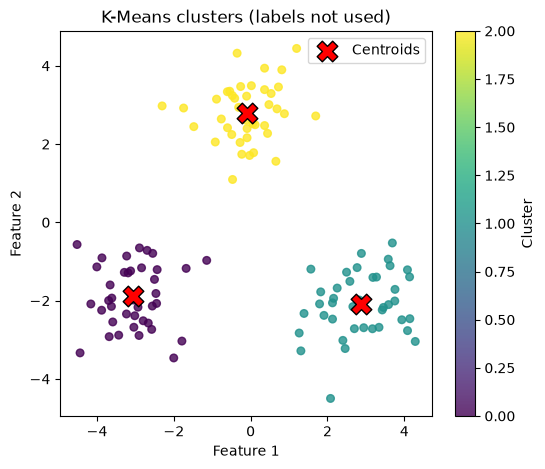

In [3]:
# Labels y are deliberately not supplied to K-Means.
cluster_ids, centroids, n_iterations = kmeans(X, k=3, seed=7)
print(f'Converged after {n_iterations} iterations')
print('Centroids:\n', centroids)
print('Cluster sizes:', np.bincount(cluster_ids, minlength=3))

fig, ax = plt.subplots(figsize=(6, 5))
points = ax.scatter(X[:, 0], X[:, 1], c=cluster_ids, cmap='viridis', s=30, alpha=0.8)
ax.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=220, c='red', edgecolor='black', label='Centroids')
ax.set(title='K-Means clusters (labels not used)', xlabel='Feature 1', ylabel='Feature 2')
ax.legend()
fig.colorbar(points, ax=ax, label='Cluster')
plt.show()

## 2. LDA implementation

For each class c, add $(x-\mu_c)(x-\mu_c)^T$ to $S_W$. Add $n_c(\mu_c-\mu)(\mu_c-\mu)^T$ to $S_B$, where $\mu$ is the overall mean. Then solve the eigenproblem for $S_W^{-1}S_B$, sort directions by eigenvalue, and retain at most C−1 components. A pseudoinverse supports singular $S_W$.

In [4]:
def lda_fit_transform(X, y, n_components=None):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)
    if X.ndim != 2 or y.ndim != 1 or len(X) != len(y):
        raise ValueError('X must be 2D and y must be a matching 1D array.')
    classes = np.unique(y)
    if len(classes) < 2:
        raise ValueError('LDA requires at least two classes.')

    overall_mean = X.mean(axis=0)
    n_features = X.shape[1]
    Sw = np.zeros((n_features, n_features), dtype=float)
    Sb = np.zeros_like(Sw)
    for class_label in classes:
        class_samples = X[y == class_label]
        class_mean = class_samples.mean(axis=0)
        centered = class_samples - class_mean
        Sw += centered.T @ centered
        difference = (class_mean - overall_mean).reshape(-1, 1)
        Sb += len(class_samples) * (difference @ difference.T)

    eigenvalues, eigenvectors = np.linalg.eig(np.linalg.pinv(Sw) @ Sb)
    order = np.argsort(eigenvalues.real)[::-1]
    max_components = min(len(classes) - 1, n_features)
    if n_components is None:
        n_components = max_components
    if not 1 <= n_components <= max_components:
        raise ValueError(f'n_components must be between 1 and {max_components}.')

    selected_values = eigenvalues[order[:n_components]].real
    directions = eigenvectors[:, order[:n_components]].real
    directions /= np.maximum(np.linalg.norm(directions, axis=0, keepdims=True), 1e-12)
    projected = (X - overall_mean) @ directions
    return projected, directions, selected_values, Sw, Sb

Within-class scatter Sw:
 [[73.474 10.424]
 [10.424 71.32 ]]
Between-class scatter Sb:
 [[704.416 -24.35 ]
 [-24.35  612.905]]
Selected eigenvalues: [11.086  7.579]
Discriminant directions (columns):
 [[ 0.786  0.574]
 [-0.618  0.819]]
Projected shape: (120, 2)


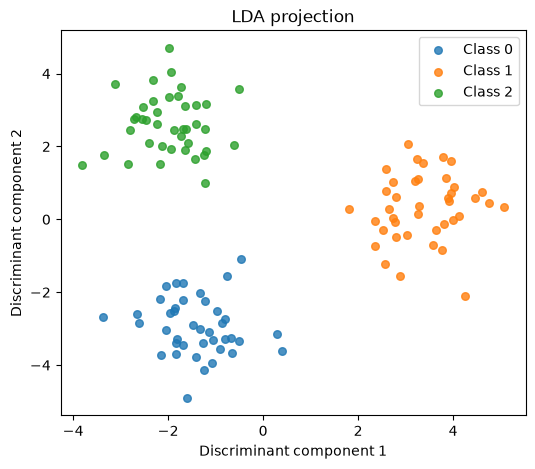

In [5]:
X_lda, directions, eigenvalues, Sw, Sb = lda_fit_transform(X, y)
print('Within-class scatter Sw:\n', Sw)
print('Between-class scatter Sb:\n', Sb)
print('Selected eigenvalues:', eigenvalues)
print('Discriminant directions (columns):\n', directions)
print('Projected shape:', X_lda.shape)

fig, ax = plt.subplots(figsize=(6, 5))
for class_id in np.unique(y):
    mask = y == class_id
    ax.scatter(X_lda[mask, 0], X_lda[mask, 1], s=30, alpha=0.8, label=f'Class {class_id}')
ax.set(title='LDA projection', xlabel='Discriminant component 1', ylabel='Discriminant component 2')
ax.legend()
plt.show()

## Conclusion

K-Means found groups from feature-space distances alone, while LDA used known labels to construct directions that emphasize class separation. The K-Means and LDA calculations are implemented directly with NumPy; only the plots use Matplotlib.